In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# 1. Imports & configuration
# ============================================================
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    precision_recall_curve, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight

HAS_XGB = False
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    pass

HAS_SMOTE = False
try:
    from imblearn.over_sampling import SMOTE
    HAS_SMOTE = True
except Exception:
    pass

HAS_SHAP = False
try:
    import shap
    HAS_SHAP = True
except Exception:
    pass

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

print({
    "xgboost": HAS_XGB,
    "smote": HAS_SMOTE,
    "shap": HAS_SHAP
})


{'xgboost': True, 'smote': True, 'shap': True}


In [ ]:
# ============================================================
# 2. Paths & data loading
# ============================================================
BASE_PATH = Path("/content/drive/MyDrive/MLScoringDataSets")

CUSTOMERS_PATH = BASE_PATH / "customers.csv"
LOANS_PATH = BASE_PATH / "loans.csv"
TRANSACTIONS_PATH = BASE_PATH / "transactions.csv"
GRAPH_PATH = BASE_PATH / "transaction_graph.graphml"

for p in [CUSTOMERS_PATH, LOANS_PATH, TRANSACTIONS_PATH]:
    assert p.exists(), f"Missing file: {p}"

customers = pd.read_csv(CUSTOMERS_PATH)
loans = pd.read_csv(LOANS_PATH)
transactions = pd.read_csv(TRANSACTIONS_PATH, low_memory=False)

def convert_date_columns(df):
    df = df.copy()
    for c in df.columns:
        if "date" in c.lower():
            df[c] = pd.to_datetime(df[c], errors="coerce")
    return df

customers = convert_date_columns(customers)
loans = convert_date_columns(loans)
transactions = convert_date_columns(transactions)

print("customers   :", customers.shape)
print("loans       :", loans.shape)
print("transactions:", transactions.shape)
print("graphml present:", GRAPH_PATH.exists())


customers   : (10000, 42)
loans       : (8000, 21)
transactions: (151727, 36)
graphml present: True


In [ ]:
# ============================================================
# 3. Quick audit
# ============================================================
def audit_df(df, name, n=3):
    print("\n" + "=" * 100)
    print(name)
    print("=" * 100)
    print("shape:", df.shape)
    display(df.head(n))
    summary = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean() * 100).round(2).values,
        "n_unique": [df[c].nunique(dropna=True) for c in df.columns]
    }).sort_values(["missing_pct", "n_unique"], ascending=[False, False])
    display(summary)
    print("duplicate rows:", df.duplicated().sum())

audit_df(customers, "customers")
audit_df(loans, "loans")
audit_df(transactions, "transactions")



customers
shape: (10000, 42)


,Customer_ID,First_Name,Last_Name,Date_of_Birth,Age,Gender,Email,Phone_Number,Street_Address,Postal_Code,City,Country,Account_Number,Card_Network,Card_Number,Card_Expiry,Account_Type,Registration_Date,Marital_Status,Education_Level,Employment_Status,Job_Type,Employment_Length,Annual_Income,Monthly_Income,Residential_Status,Number_of_Dependents,Account_Age_Months,Savings_Balance,total_tx_amount,avg_tx_amount,tx_count,fraud_count,intl_count,cross_border,high_amount_count,aml_count,Risk_Score,Degree_Centrality,Closeness_Centrality,Betweenness_Centrality,PageRank
0,CUST_00001,Zulfiye,Can,2007-08-27,18,Female,zulfiye_can@yahoo.com,(770)560-6538x8583,168 Anthony Groves Suite 834,79092,Antalya,Turkey,TR5239887210117454,Discover,6011********5173,08/25,Personal,2024-10-30,Single,High School,Student,Student,0,1966.86,163.90,Rent,1,8,1976.63,101.46,33.820000,3.0,0.0,0.0,3.0,0.0,0.0,15.99,0.000106,0.051719,0.000015,0.000019
1,CUST_00002,Olivia,Lim,1976-11-22,49,Female,olivia.lim769@protonmail.com,(01632) 960265,5 Bradley Valleys,BS4 4DT,Singapore,Singapore,SG4917906726565826,Mastercard,5348********4477,05/29,Personal,2022-04-02,Widowed,High School,Employed,Government,4,36264.76,3022.06,Owner,3,39,71899.41,10301.17,936.470000,11.0,0.0,1.0,7.0,1.0,0.0,35.76,0.000146,0.000000,0.000000,0.000008
2,CUST_00003,Makoto,Ito,2002-07-26,23,Male,makoto.ito@gmail.com,2516034074,877 Vanessa Gardens Apt. 995,65616,Kobe,Japan,JP9043945006587355,Amex,3720*******3114,10/26,Joint,2022-10-01,Single,Master,Employed,Healthcare,5,44652.64,3721.05,Rent,0,33,66776.59,36294.85,4032.761111,9.0,0.0,0.0,6.0,0.0,0.0,26.63,0.000160,0.050414,0.000062,0.000016


,column,dtype,missing_count,missing_pct,n_unique
0,Customer_ID,object,0,0.0,10000
12,Account_Number,object,0,0.0,10000
28,Savings_Balance,float64,0,0.0,9994
6,Email,object,0,0.0,9977
14,Card_Number,object,0,0.0,9965
7,Phone_Number,object,0,0.0,9728
8,Street_Address,object,0,0.0,9711
23,Annual_Income,float64,0,0.0,9704
30,avg_tx_amount,float64,0,0.0,9618
29,total_tx_amount,float64,0,0.0,9601


duplicate rows: 0

loans
shape: (8000, 21)


,Loan_ID,Customer_ID,Loan_Type,Loan_Amount,Loan_Purpose,Origination_Date,Credit_Score,Interest_Rate,Loan_Term_Months,Monthly_Installment,Number_of_Active_Loans,Total_Debt,Debt_to_Income,Loan_to_Income,Previous_Defaults,Days_Past_Due,Payment_History_Ratio,Credit_Utilization,Collateral_Type,Default_Flag,Loan_Status
0,LOAN_00001,CUST_03997,Auto,1770.83,Motorcycle,2025-04-01,545,9.31,72,32.19,1,3929.99,0.2548,1.1683,0,6,0.9353,0.6035,Used Vehicle,0,Grace Period
1,LOAN_00002,CUST_03369,Personal,39378.32,Relocation,2022-12-10,568,8.25,36,1238.52,4,85589.85,1.5000,1.4792,1,22,0.8663,0.0187,Jewelry,1,Default
2,LOAN_00003,CUST_02490,Personal,15398.17,Emergency Fund,2020-03-18,638,6.39,36,471.17,4,29586.12,1.1970,0.8150,1,9,0.8698,0.3971,NaN,0,Grace Period


,column,dtype,missing_count,missing_pct,n_unique
18,Collateral_Type,object,1280,16.0,11
0,Loan_ID,object,0,0.0,8000
11,Total_Debt,float64,0,0.0,7997
3,Loan_Amount,float64,0,0.0,7898
9,Monthly_Installment,float64,0,0.0,7772
13,Loan_to_Income,float64,0,0.0,6805
1,Customer_ID,object,0,0.0,5582
12,Debt_to_Income,float64,0,0.0,5119
17,Credit_Utilization,float64,0,0.0,4972
16,Payment_History_Ratio,float64,0,0.0,2382


duplicate rows: 0

transactions
shape: (151727, 36)


,Transaction_ID,Customer_ID,Beneficiary_ID,Beneficiary_Name,Is_Internal_Transfer,Beneficiary_Country,Beneficiary_City,Cross_Border_Transfer,Transaction_Date,Hour,Day_of_Week,Transaction_Type,Merchant_Category,Merchant_Name,Transaction_Amount,Currency,Reference,Channel,Device_Type,Terminal_ID,IP_Address,User_Agent,IP_Anomaly_Flag,Card_Network,Card_Number,Card_Clone_Flag,Transaction_Country,Transaction_City,Is_International,Daily_Tx_Count,Rapid_Succession_Flag,Amount_Zscore,High_Amount_Flag,Balance_Tx_Ratio,Fraud_Flag,AML_Pattern
0,TXN_000001,CUST_06415,CUST_08191,Tomas Rios,1,Argentina,Cordoba,1,2024-06-30 00:05:40,0,6,Transfer,Food,"Lee, Horton and Snyder Kitchen",1218.86,USD,REF-20240630-381695,Online,Desktop,NaN,40.250.186.147,Mozilla/5.0 (X11; Linux i686) AppleWebKit/532....,0,Visa,4665********6228,0,USA,Phoenix,0,1,0,-0.4425,0,93.7979,0,NaN
1,TXN_000002,CUST_01980,CUST_04935,Monika Hoffmann,1,Germany,Stuttgart,0,2024-06-30 00:05:45,0,6,Transfer,Healthcare,Duncan-Williams Medical,37.76,EUR,REF-20240630-754745,Mobile_App,Desktop,NaN,141.15.212.208,Mozilla/5.0 (iPod; U; CPU iPhone OS 4_1 like M...,0,Visa,4288********0256,0,Germany,Hamburg,0,1,0,-0.8209,0,68.0132,0,NaN
2,TXN_000003,CUST_03898,EXT_804459,Ben Klein,0,Germany,Munich,1,2024-06-30 00:11:34,0,6,Payment,Clothing,Clarke-Ramirez Wear,171.97,JPY,REF-20240630-971205,Mobile_App,Mobile,NaN,212.200.78.203,Opera/8.88.(Windows NT 6.2; kk-KZ) Presto/2.9....,0,Discover,6011********2637,0,Japan,Tokyo,0,1,0,-1.3379,0,350.5873,0,NaN


,column,dtype,missing_count,missing_pct,n_unique
35,AML_Pattern,object,150000,98.86,4
19,Terminal_ID,object,91448,60.27,58471
20,IP_Address,object,75542,49.79,5000
21,User_Agent,object,75542,49.79,491
0,Transaction_ID,object,0,0.00,151727
16,Reference,object,0,0.00,151688
8,Transaction_Date,datetime64[ns],0,0.00,151265
33,Balance_Tx_Ratio,float64,0,0.00,146219
14,Transaction_Amount,float64,0,0.00,94521
2,Beneficiary_ID,object,0,0.00,74867


duplicate rows: 0


## Notes de correction

Cette version corrige les problèmes classiques du notebook initial :
- cellules dans le mauvais ordre,
- variables utilisées avant leur définition,
- dépendance forte à un objet `G` non garanti,
- plusieurs fonctions de prédiction concurrentes,
- sélection de features incohérente entre entraînement et prédiction.

Ici, tout est remis dans un pipeline unique, exécutable de haut en bas.


In [ ]:
# ============================================================
# 4. Target definition
# ============================================================
def derive_target(loans_df):
    loans_df = loans_df.copy()

    if "Default_Flag" in loans_df.columns:
        loans_df["target_default"] = pd.to_numeric(loans_df["Default_Flag"], errors="coerce").fillna(0).astype(int)
        return loans_df, "target_default"

    if "Loan_Status" in loans_df.columns:
        bad_keywords = ["default", "charged", "write", "late", "delinquent", "unpaid", "loss"]
        loans_df["target_default"] = loans_df["Loan_Status"].astype(str).str.lower().apply(
            lambda x: int(any(k in x for k in bad_keywords))
        )
        return loans_df, "target_default"

    if "Days_Past_Due" in loans_df.columns:
        loans_df["target_default"] = (pd.to_numeric(loans_df["Days_Past_Due"], errors="coerce").fillna(0) >= 90).astype(int)
        return loans_df, "target_default"

    raise ValueError("No target could be derived from loans.csv")

loans, TARGET = derive_target(loans)
print("TARGET =", TARGET)
display(loans[TARGET].value_counts(dropna=False).to_frame("count"))
display((loans[TARGET].value_counts(normalize=True) * 100).round(2).to_frame("pct"))


TARGET = target_default


,count
target_default,
0,5965
1,2035


,pct
target_default,
0,74.56
1,25.44


In [ ]:
# ============================================================
# 5. Graph features
# ============================================================
def build_graph_features(graph_path, transactions_df):
    if graph_path.exists():
        print("Loading GraphML...")
        G = nx.read_graphml(graph_path)
        print(f"nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")

        degree = nx.degree_centrality(G)
        pagerank = nx.pagerank(G)

        if G.number_of_nodes() <= 3000:
            betweenness = nx.betweenness_centrality(G)
            closeness = nx.closeness_centrality(G)
        else:
            betweenness = {n: np.nan for n in G.nodes()}
            closeness = {n: np.nan for n in G.nodes()}

        return pd.DataFrame({
            "Customer_ID": list(degree.keys()),
            "graph_degree_centrality": list(degree.values()),
            "graph_pagerank": [pagerank.get(k, np.nan) for k in degree.keys()],
            "graph_betweenness": [betweenness.get(k, np.nan) for k in degree.keys()],
            "graph_closeness": [closeness.get(k, np.nan) for k in degree.keys()],
        })

    print("GraphML not found -> creating proxy graph from internal transfers")

    if not {"Customer_ID", "Beneficiary_ID", "Transaction_Amount"}.issubset(transactions_df.columns):
        return pd.DataFrame(columns=[
            "Customer_ID",
            "graph_degree_centrality_proxy",
            "graph_pagerank_proxy",
            "graph_out_degree_proxy",
            "graph_in_degree_proxy"
        ])

    internal_tx = transactions_df[
        transactions_df["Beneficiary_ID"].astype(str).str.startswith("CUST_")
    ][["Customer_ID", "Beneficiary_ID", "Transaction_Amount"]].copy()

    G = nx.DiGraph()
    for row in internal_tx.itertuples(index=False):
        src = row.Customer_ID
        dst = row.Beneficiary_ID
        w = float(row.Transaction_Amount)
        if G.has_edge(src, dst):
            G[src][dst]["weight"] += w
            G[src][dst]["count"] += 1
        else:
            G.add_edge(src, dst, weight=w, count=1)

    if G.number_of_nodes() == 0:
        return pd.DataFrame(columns=[
            "Customer_ID",
            "graph_degree_centrality_proxy",
            "graph_pagerank_proxy",
            "graph_out_degree_proxy",
            "graph_in_degree_proxy"
        ])

    degree = nx.degree_centrality(G)
    pagerank = nx.pagerank(G, weight="weight")
    out_degree = dict(G.out_degree())
    in_degree = dict(G.in_degree())

    return pd.DataFrame({
        "Customer_ID": list(degree.keys()),
        "graph_degree_centrality_proxy": list(degree.values()),
        "graph_pagerank_proxy": [pagerank.get(k, np.nan) for k in degree.keys()],
        "graph_out_degree_proxy": [out_degree.get(k, 0) for k in degree.keys()],
        "graph_in_degree_proxy": [in_degree.get(k, 0) for k in degree.keys()],
    })

graph_features = build_graph_features(GRAPH_PATH, transactions)
display(graph_features.head())


Loading GraphML...
nodes=75154, edges=151727


,Customer_ID,graph_degree_centrality,graph_pagerank,graph_betweenness,graph_closeness
0,CUST_00001,0.000106,0.000019,NaN,NaN
1,CUST_00002,0.000146,0.000008,NaN,NaN
2,CUST_00003,0.000160,0.000016,NaN,NaN
3,CUST_00004,0.000133,0.000032,NaN,NaN
4,CUST_00005,0.000133,0.000020,NaN,NaN


In [ ]:
# ============================================================
# 6. Feature engineering
# ============================================================
def add_customer_features(customers_df, ref_date):
    df = customers_df.copy()

    if "Date_of_Birth" in df.columns:
        df["Age_from_DOB"] = ((ref_date - df["Date_of_Birth"]).dt.days / 365.25).round(1)

    if "Registration_Date" in df.columns:
        df["Customer_Tenure_Days"] = (ref_date - df["Registration_Date"]).dt.days

    if {"Annual_Income", "Number_of_Dependents"}.issubset(df.columns):
        df["Income_Per_Dependent"] = df["Annual_Income"] / (df["Number_of_Dependents"].fillna(0) + 1)

    if {"Savings_Balance", "Annual_Income"}.issubset(df.columns):
        df["Savings_to_Income"] = df["Savings_Balance"] / df["Annual_Income"].replace(0, np.nan)

    return df

def aggregate_transactions_by_customer(transactions_df):
    tx = transactions_df.copy()

    if "Transaction_Type" in tx.columns:
        tx["is_credit"] = (tx["Transaction_Type"].astype(str).str.lower() == "credit").astype(int)
        tx["is_debit"] = tx["Transaction_Type"].astype(str).str.lower().isin(["debit", "payment"]).astype(int)
        tx["is_transfer"] = (tx["Transaction_Type"].astype(str).str.lower() == "transfer").astype(int)
    else:
        tx["is_credit"] = 0
        tx["is_debit"] = 0
        tx["is_transfer"] = 0

    if "Transaction_Date" in tx.columns:
        tx["txn_month"] = tx["Transaction_Date"].dt.to_period("M").astype(str)
    else:
        tx["txn_month"] = "unknown"

    for c in [
        "High_Amount_Flag", "Rapid_Succession_Flag", "Fraud_Flag", "IP_Anomaly_Flag",
        "Card_Clone_Flag", "Is_International", "Cross_Border_Transfer"
    ]:
        if c not in tx.columns:
            tx[c] = 0

    for c in ["Beneficiary_ID", "Beneficiary_Country", "Beneficiary_City", "Merchant_Name", "Merchant_Category", "Channel", "Card_Network", "AML_Pattern"]:
        if c not in tx.columns:
            tx[c] = np.nan

    count_col = "Transaction_ID" if "Transaction_ID" in tx.columns else "Transaction_Amount"

    basic = tx.groupby("Customer_ID").agg(
        tx_count=(count_col, "count"),
        tx_amount_sum=("Transaction_Amount", "sum"),
        tx_amount_mean=("Transaction_Amount", "mean"),
        tx_amount_std=("Transaction_Amount", "std"),
        tx_amount_max=("Transaction_Amount", "max"),
        tx_credit_count=("is_credit", "sum"),
        tx_debit_count=("is_debit", "sum"),
        tx_transfer_count=("is_transfer", "sum"),
        tx_high_amount_count=("High_Amount_Flag", "sum"),
        tx_rapid_succession_count=("Rapid_Succession_Flag", "sum"),
        tx_fraud_count=("Fraud_Flag", "sum"),
        tx_ip_anomaly_count=("IP_Anomaly_Flag", "sum"),
        tx_card_clone_count=("Card_Clone_Flag", "sum"),
        tx_international_count=("Is_International", "sum"),
        tx_cross_border_count=("Cross_Border_Transfer", "sum"),
        tx_unique_beneficiaries=("Beneficiary_ID", "nunique"),
        tx_unique_countries=("Beneficiary_Country", "nunique"),
        tx_unique_cities=("Beneficiary_City", "nunique"),
        tx_unique_merchants=("Merchant_Name", "nunique"),
        tx_unique_categories=("Merchant_Category", "nunique"),
        tx_months_active=("txn_month", "nunique")
    ).reset_index()

    def advanced(group):
        monthly_total = group.groupby("txn_month")["Transaction_Amount"].sum()
        monthly_credit = group.loc[group["is_credit"] == 1].groupby("txn_month")["Transaction_Amount"].sum()
        monthly_debit = group.loc[group["is_debit"] == 1].groupby("txn_month")["Transaction_Amount"].sum()

        top_benef = group["Beneficiary_ID"].value_counts(normalize=True, dropna=False)
        top_cat = group["Merchant_Category"].value_counts(normalize=True, dropna=False)

        return pd.Series({
            "tx_credit_amount_sum": group.loc[group["is_credit"] == 1, "Transaction_Amount"].sum(),
            "tx_debit_amount_sum": group.loc[group["is_debit"] == 1, "Transaction_Amount"].sum(),
            "tx_transfer_amount_sum": group.loc[group["is_transfer"] == 1, "Transaction_Amount"].sum(),
            "tx_monthly_amount_mean": monthly_total.mean() if len(monthly_total) else np.nan,
            "tx_monthly_amount_std": monthly_total.std(ddof=0) if len(monthly_total) > 1 else np.nan,
            "tx_monthly_credit_mean": monthly_credit.mean() if len(monthly_credit) else 0.0,
            "tx_monthly_debit_mean": monthly_debit.mean() if len(monthly_debit) else 0.0,
            "tx_income_irregularity": (monthly_credit.std(ddof=0) / (monthly_credit.mean() + 1e-6)) if len(monthly_credit) > 1 else np.nan,
            "tx_expense_volatility": (monthly_debit.std(ddof=0) / (monthly_debit.mean() + 1e-6)) if len(monthly_debit) > 1 else np.nan,
            "tx_aml_pattern_count": group["AML_Pattern"].notna().sum(),
            "tx_channel_online_share": (group["Channel"].astype(str) == "Online").mean(),
            "tx_channel_atm_share": (group["Channel"].astype(str) == "ATM").mean(),
            "tx_card_network_diversity": group["Card_Network"].nunique(),
            "tx_top_beneficiary_concentration": top_benef.iloc[0] if len(top_benef) else np.nan,
            "tx_top_category_concentration": top_cat.iloc[0] if len(top_cat) else np.nan,
        })

    advanced_df = tx.groupby("Customer_ID").apply(advanced).reset_index()
    out = basic.merge(advanced_df, on="Customer_ID", how="left")
    out["tx_credit_share"] = out["tx_credit_count"] / out["tx_count"].replace(0, np.nan)
    out["tx_cashflow_net"] = out["tx_credit_amount_sum"].fillna(0) - out["tx_debit_amount_sum"].fillna(0)
    out["has_tx_history"] = out["tx_count"].fillna(0).gt(0).astype(int)
    return out

ref_date = loans["Origination_Date"].max() if "Origination_Date" in loans.columns else pd.Timestamp.today()
customers_feat = add_customer_features(customers, ref_date)
tx_agg = aggregate_transactions_by_customer(transactions)

display(customers_feat.head())
display(tx_agg.head())


,Customer_ID,First_Name,Last_Name,Date_of_Birth,Age,Gender,Email,Phone_Number,Street_Address,Postal_Code,City,Country,Account_Number,Card_Network,Card_Number,Card_Expiry,Account_Type,Registration_Date,Marital_Status,Education_Level,Employment_Status,Job_Type,Employment_Length,Annual_Income,Monthly_Income,Residential_Status,Number_of_Dependents,Account_Age_Months,Savings_Balance,total_tx_amount,avg_tx_amount,tx_count,fraud_count,intl_count,cross_border,high_amount_count,aml_count,Risk_Score,Degree_Centrality,Closeness_Centrality,Betweenness_Centrality,PageRank,Age_from_DOB,Customer_Tenure_Days,Income_Per_Dependent,Savings_to_Income
0,CUST_00001,Zulfiye,Can,2007-08-27,18,Female,zulfiye_can@yahoo.com,(770)560-6538x8583,168 Anthony Groves Suite 834,79092,Antalya,Turkey,TR5239887210117454,Discover,6011********5173,08/25,Personal,2024-10-30,Single,High School,Student,Student,0,1966.86,163.90,Rent,1,8,1976.63,101.46,33.820000,3.0,0.0,0.0,3.0,0.0,0.0,15.99,0.000106,0.051719,0.000015,0.000019,17.8,213,983.430000,1.004967
1,CUST_00002,Olivia,Lim,1976-11-22,49,Female,olivia.lim769@protonmail.com,(01632) 960265,5 Bradley Valleys,BS4 4DT,Singapore,Singapore,SG4917906726565826,Mastercard,5348********4477,05/29,Personal,2022-04-02,Widowed,High School,Employed,Government,4,36264.76,3022.06,Owner,3,39,71899.41,10301.17,936.470000,11.0,0.0,1.0,7.0,1.0,0.0,35.76,0.000146,0.000000,0.000000,0.000008,48.5,1155,9066.190000,1.982625
2,CUST_00003,Makoto,Ito,2002-07-26,23,Male,makoto.ito@gmail.com,2516034074,877 Vanessa Gardens Apt. 995,65616,Kobe,Japan,JP9043945006587355,Amex,3720*******3114,10/26,Joint,2022-10-01,Single,Master,Employed,Healthcare,5,44652.64,3721.05,Rent,0,33,66776.59,36294.85,4032.761111,9.0,0.0,0.0,6.0,0.0,0.0,26.63,0.000160,0.050414,0.000062,0.000016,22.8,973,44652.640000,1.495468
3,CUST_00004,Jose,Almeida,1984-10-19,41,Male,josealmeida@protonmail.com,+55 71 2945-7719,"Rua Vargas, 672",41917625,Sao Paulo,Brazil,BR3534126971514774,Visa,4389********9751,08/26,Trust,2023-12-31,Single,Bachelor,Employed,Manufacturing,2,19625.48,1635.46,Rent,0,18,33481.60,3161.34,790.335000,4.0,0.0,0.0,2.0,0.0,0.0,9.66,0.000133,0.051686,0.000010,0.000032,40.6,517,19625.480000,1.706027
4,CUST_00005,Shweta,Agarwal,1982-08-25,43,Female,shwetaagarwal@protonmail.com,+910451353159,H.No. 630\nSankaran Nagar,482639,Kolkata,India,IN0944997437816513,Mastercard,5420********7233,10/25,Personal,2023-01-31,Married,High School,Employed,IT/Tech,4,10146.07,845.51,Owner,2,29,8296.48,1148.22,164.031429,7.0,0.0,1.0,3.0,0.0,0.0,16.77,0.000133,0.047403,0.000130,0.000021,42.8,851,3382.023333,0.817704


,Customer_ID,tx_count,tx_amount_sum,tx_amount_mean,tx_amount_std,tx_amount_max,tx_credit_count,tx_debit_count,tx_transfer_count,tx_high_amount_count,tx_rapid_succession_count,tx_fraud_count,tx_ip_anomaly_count,tx_card_clone_count,tx_international_count,tx_cross_border_count,tx_unique_beneficiaries,tx_unique_countries,tx_unique_cities,tx_unique_merchants,tx_unique_categories,tx_months_active,tx_credit_amount_sum,tx_debit_amount_sum,tx_transfer_amount_sum,tx_monthly_amount_mean,tx_monthly_amount_std,tx_monthly_credit_mean,tx_monthly_debit_mean,tx_income_irregularity,tx_expense_volatility,tx_aml_pattern_count,tx_channel_online_share,tx_channel_atm_share,tx_card_network_diversity,tx_top_beneficiary_concentration,tx_top_category_concentration,tx_credit_share,tx_cashflow_net,has_tx_history
0,CUST_00001,3,101.46,33.820000,16.910804,44.03,0,1,2,0,0,0,0,0,0,3,3,3,3,3,3,3,0.00,44.03,57.43,33.820000,13.807614,0.00,44.030000,NaN,NaN,0.0,0.000000,0.000000,1.0,0.333333,0.333333,0.000000,-44.03,1
1,CUST_00002,11,10301.17,936.470000,769.379206,2922.07,0,7,4,1,0,0,0,0,1,7,11,7,8,11,8,9,0.00,8768.53,1532.64,1144.574444,788.010671,0.00,1252.647143,NaN,0.596121,0.0,0.181818,0.272727,1.0,0.090909,0.363636,0.000000,-8768.53,1
2,CUST_00003,9,36294.85,4032.761111,6244.088216,18191.30,0,7,2,0,0,0,1,0,0,6,9,6,7,9,6,6,0.00,16981.01,19313.84,6049.141667,7100.720099,0.00,4245.252500,NaN,1.278329,0.0,0.000000,0.111111,1.0,0.111111,0.333333,0.000000,-16981.01,1
3,CUST_00004,4,3161.34,790.335000,257.029336,1116.78,2,1,1,0,0,0,0,0,0,2,4,3,3,4,3,3,1871.80,799.69,489.85,1053.780000,391.349114,935.90,799.690000,0.193269,NaN,0.0,0.000000,0.500000,1.0,0.250000,0.500000,0.500000,1072.11,1
4,CUST_00005,7,1148.22,164.031429,58.633554,242.92,1,4,2,0,0,0,0,0,1,3,7,4,4,7,4,6,169.77,675.81,302.64,191.370000,80.017976,169.77,225.270000,NaN,0.389124,0.0,0.285714,0.142857,1.0,0.142857,0.428571,0.142857,-506.04,1


In [ ]:
# ============================================================
# 7. Final analytical table
# ============================================================
analytic_df = loans.copy()
analytic_df = analytic_df.merge(customers_feat, on="Customer_ID", how="left")
analytic_df = analytic_df.merge(tx_agg, on="Customer_ID", how="left")
if not graph_features.empty:
    analytic_df = analytic_df.merge(graph_features, on="Customer_ID", how="left")

if {"Monthly_Installment", "Monthly_Income"}.issubset(analytic_df.columns):
    analytic_df["monthly_installment_to_income"] = analytic_df["Monthly_Installment"] / analytic_df["Monthly_Income"].replace(0, np.nan)

if {"Loan_Amount", "Annual_Income"}.issubset(analytic_df.columns):
    analytic_df["loan_amount_to_income"] = analytic_df["Loan_Amount"] / analytic_df["Annual_Income"].replace(0, np.nan)

if {"Loan_Amount", "Savings_Balance"}.issubset(analytic_df.columns):
    analytic_df["loan_amount_to_savings"] = analytic_df["Loan_Amount"] / analytic_df["Savings_Balance"].replace(0, np.nan)

if {"Total_Debt", "Annual_Income"}.issubset(analytic_df.columns):
    analytic_df["debt_to_annual_income"] = analytic_df["Total_Debt"] / analytic_df["Annual_Income"].replace(0, np.nan)

if {"Customer_ID", "Loan_ID"}.issubset(analytic_df.columns):
    analytic_df["loan_count_per_customer"] = analytic_df.groupby("Customer_ID")["Loan_ID"].transform("count")

LEAKAGE_COLS = [
    TARGET, "Default_Flag", "Loan_Status", "Days_Past_Due", "Payment_History_Ratio",
    "Risk_Score", "First_Name", "Last_Name", "Email", "Phone_Number", "Street_Address",
    "Postal_Code", "City", "Account_Number", "Card_Number", "Card_Expiry"
]
ID_COLS = [c for c in ["Loan_ID", "Customer_ID"] if c in analytic_df.columns]

FEATURES = [c for c in analytic_df.columns if c not in set(LEAKAGE_COLS + ID_COLS)]

print("analytic_df shape:", analytic_df.shape)
print("number of features:", len(FEATURES))

features_catalog = pd.DataFrame({
    "feature": FEATURES,
    "dtype": [analytic_df[c].dtype for c in FEATURES],
    "missing_pct": [round(analytic_df[c].isna().mean() * 100, 2) for c in FEATURES],
    "n_unique": [analytic_df[c].nunique(dropna=True) for c in FEATURES]
}).sort_values(["dtype", "missing_pct", "n_unique"], ascending=[True, False, False])

display(features_catalog.head(60))


analytic_df shape: (8000, 115)
number of features: 97


,feature,dtype,missing_pct,n_unique
90,graph_betweenness,float64,100.00,0
91,graph_closeness,float64,100.00,0
77,tx_income_irregularity,float64,51.48,2700
78,tx_expense_volatility,float64,15.71,4713
74,tx_monthly_amount_std,float64,7.91,5134
52,tx_amount_std,float64,7.49,5156
73,tx_monthly_amount_mean,float64,3.09,5396
51,tx_amount_mean,float64,3.09,5395
50,tx_amount_sum,float64,3.09,5389
53,tx_amount_max,float64,3.09,5360


Target distribution


,count
target_default,
0,5965
1,2035


,pct
target_default,
0,74.56
1,25.44


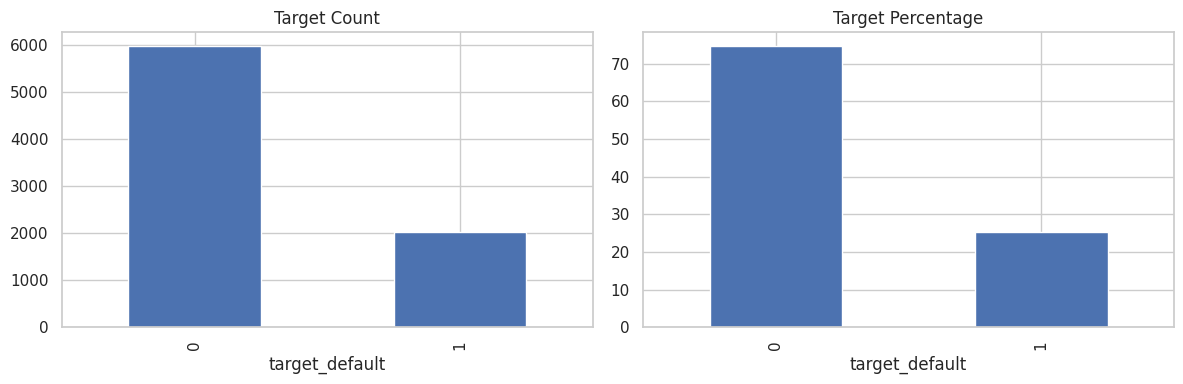

,corr_with_target
Previous_Defaults,0.179579
Credit_Score,-0.165083
Interest_Rate,0.148684
Debt_to_Income,0.142897
Monthly_Income,-0.113445
Annual_Income,-0.113445
monthly_installment_to_income,0.112664
Credit_Utilization,0.096071
Income_Per_Dependent,-0.088962
Number_of_Active_Loans,0.081861


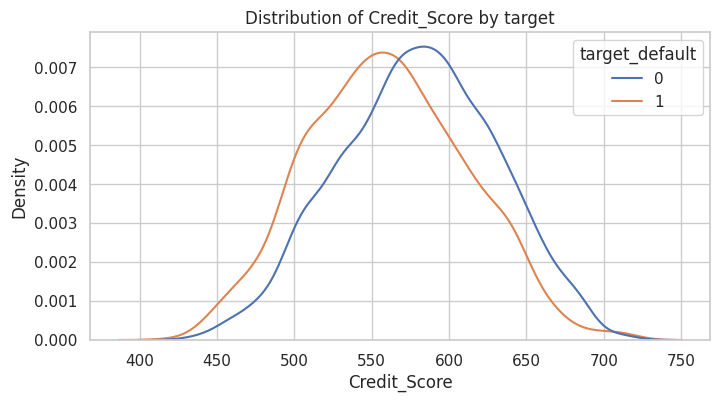

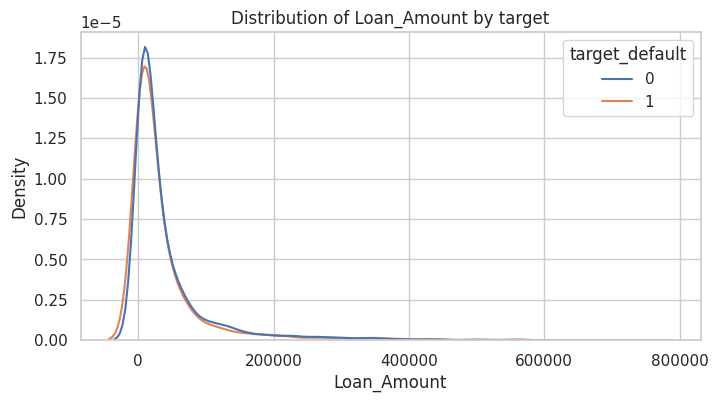

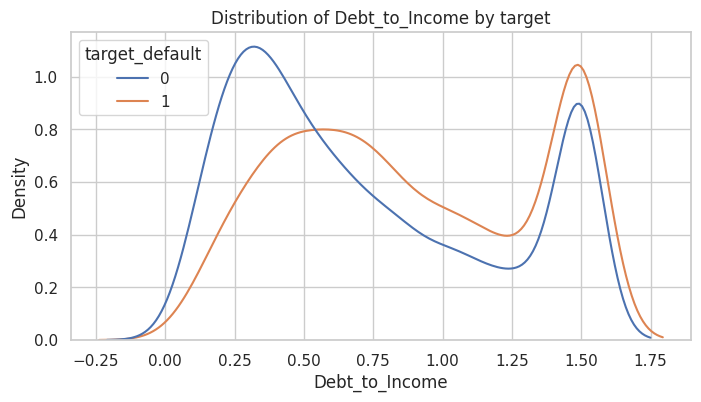

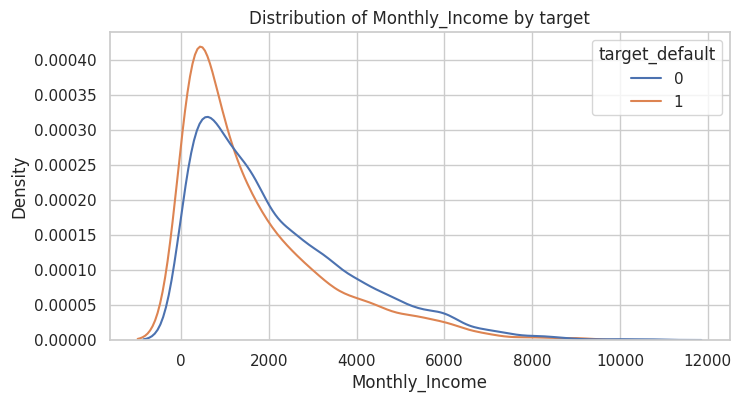

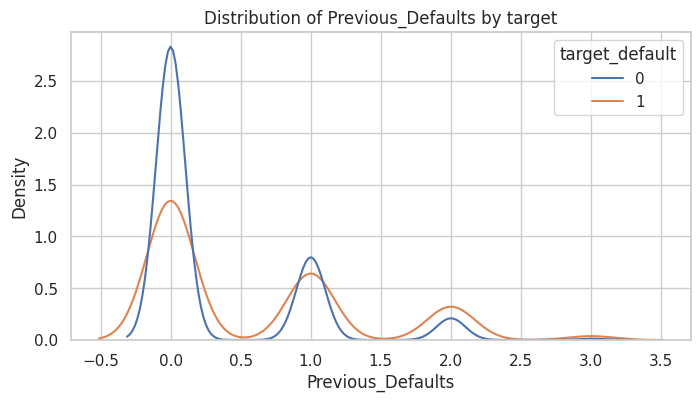

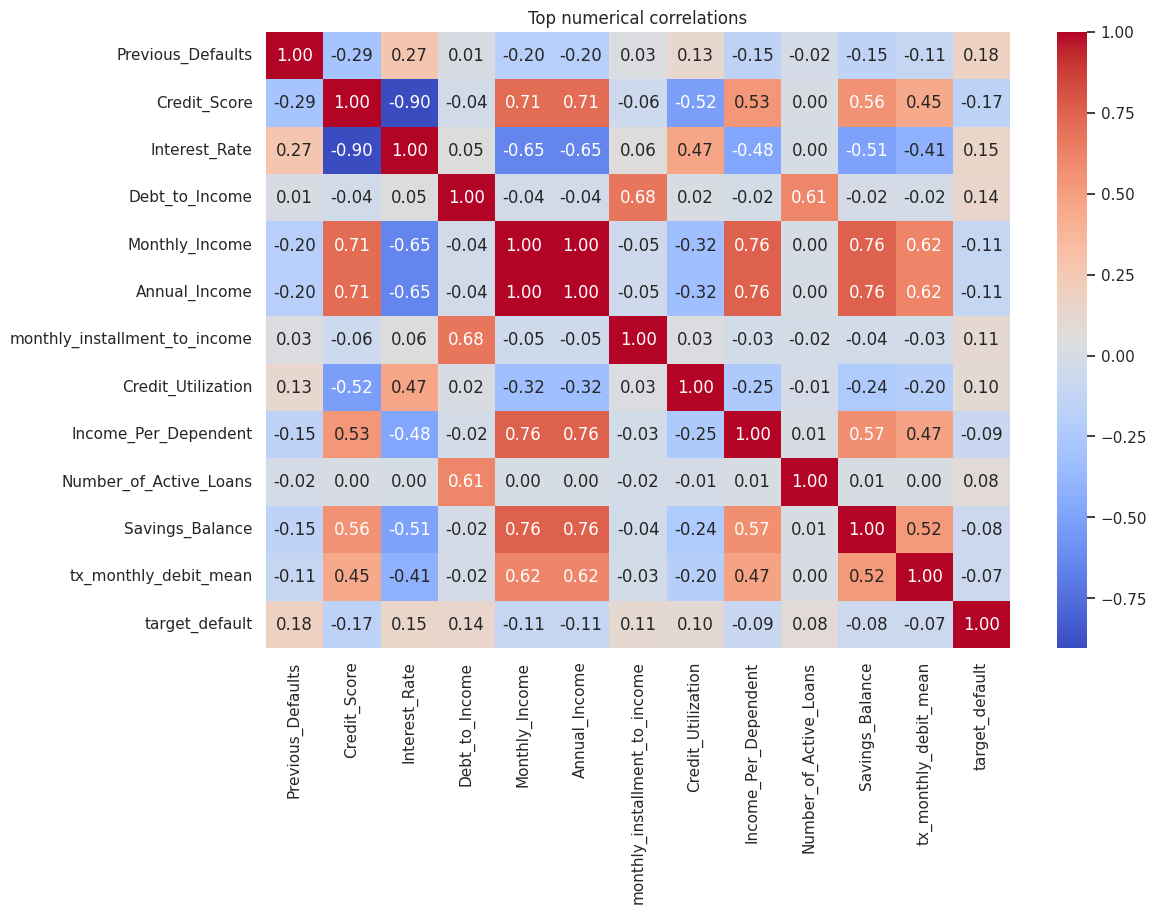

In [ ]:
# ============================================================
# 8. EDA
# ============================================================
print("Target distribution")
display(analytic_df[TARGET].value_counts(dropna=False).to_frame("count"))
display((analytic_df[TARGET].value_counts(normalize=True) * 100).round(2).to_frame("pct"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
analytic_df[TARGET].value_counts().plot(kind="bar", ax=axes[0], title="Target Count")
analytic_df[TARGET].value_counts(normalize=True).mul(100).plot(kind="bar", ax=axes[1], title="Target Percentage")
plt.tight_layout()
plt.show()

num_cols = analytic_df[FEATURES + [TARGET]].select_dtypes(include=np.number).columns.tolist()
corr_target = analytic_df[num_cols].corr(numeric_only=True)[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
display(corr_target.head(20).to_frame("corr_with_target"))

important_plots = [c for c in ["Credit_Score", "Loan_Amount", "Debt_to_Income", "Monthly_Income", "Previous_Defaults"] if c in analytic_df.columns]
for col in important_plots:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=analytic_df, x=col, hue=TARGET, common_norm=False)
    plt.title(f"Distribution of {col} by target")
    plt.show()

plt.figure(figsize=(12, 8))
corr_top = corr_target.head(12).index.tolist()
if corr_top:
    sns.heatmap(analytic_df[corr_top + [TARGET]].corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
    plt.title("Top numerical correlations")
    plt.show()


In [ ]:
# ============================================================
# 9. Train / validation / test split
# ============================================================
if "Origination_Date" in analytic_df.columns and analytic_df["Origination_Date"].notna().sum() > 0:
    model_df = analytic_df.sort_values("Origination_Date").reset_index(drop=True).copy()
    n = len(model_df)
    train_end = int(n * 0.70)
    valid_end = int(n * 0.85)

    train_df = model_df.iloc[:train_end].copy()
    valid_df = model_df.iloc[train_end:valid_end].copy()
    test_df = model_df.iloc[valid_end:].copy()
    print("Chronological split used.")
else:
    train_df, temp_df = train_test_split(
        analytic_df, test_size=0.30, random_state=42, stratify=analytic_df[TARGET]
    )
    valid_df, test_df = train_test_split(
        temp_df, test_size=0.50, random_state=42, stratify=temp_df[TARGET]
    )
    print("Stratified random split used.")

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test :", test_df.shape)


Chronological split used.
Train: (5600, 115)
Valid: (1200, 115)
Test : (1200, 115)


In [ ]:
# ============================================================
# 10. Preprocessing
# ============================================================
NUM_FEATURES = train_df[FEATURES].select_dtypes(include=np.number).columns.tolist()
CAT_FEATURES = [c for c in FEATURES if c not in NUM_FEATURES]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), NUM_FEATURES),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_ohe())
        ]), CAT_FEATURES)
    ],
    remainder="drop"
)

X_train = preprocessor.fit_transform(train_df[FEATURES])
X_valid = preprocessor.transform(valid_df[FEATURES])
X_test = preprocessor.transform(test_df[FEATURES])

y_train = train_df[TARGET].astype(int).values
y_valid = valid_df[TARGET].astype(int).values
y_test = test_df[TARGET].astype(int).values

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("X_test :", X_test.shape)


X_train: (5600, 6087)
X_valid: (1200, 6087)
X_test : (1200, 6087)


In [ ]:
# ============================================================
# 11. Class imbalance handling
# ============================================================
scale_pos_weight = (len(y_train) - y_train.sum()) / max(y_train.sum(), 1)
print("scale_pos_weight:", round(scale_pos_weight, 4))

USE_SMOTE = False
if USE_SMOTE and HAS_SMOTE:
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print("SMOTE applied:", X_train_res.shape)
else:
    X_train_res, y_train_res = X_train, y_train
    print("SMOTE not used.")


scale_pos_weight: 3.0288
SMOTE not used.


In [ ]:
# ============================================================
# 12. Model training
# ============================================================
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=3000, class_weight="balanced", solver="liblinear", random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=5, class_weight="balanced_subsample",
        random_state=42, n_jobs=-1
    )
}

if HAS_XGB:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=42,
        scale_pos_weight=float(scale_pos_weight),
        n_jobs=4
    )

def ks_statistic(y_true, y_pred_proba):
    df = pd.DataFrame({'y_true': y_true, 'y_pred_proba': y_pred_proba})
    df = df.sort_values('y_pred_proba')
    # Calculate cumulative distributions for both classes
    cum_dist_0 = df[df['y_true'] == 0]['y_pred_proba'].rank(pct=True)
    cum_dist_1 = df[df['y_true'] == 1]['y_pred_proba'].rank(pct=True)

    # Merge the cumulative distributions based on predicted probabilities
    merged = pd.concat([cum_dist_0, cum_dist_1], axis=1).fillna(method='ffill').fillna(method='bfill')
    merged.columns = ['cum_dist_0', 'cum_dist_1']

    # Calculate the maximum absolute difference between the cumulative distributions
    ks_value = np.max(np.abs(merged['cum_dist_0'] - merged['cum_dist_1']))
    return ks_value

def evaluate_models(models, X_train, y_train, X_valid, y_valid):
    rows = []
    fitted = {}
    probs = {}

    for name, model in models.items():
        print("Training", name)
        model.fit(X_train, y_train)
        prob = model.predict_proba(X_valid)[:, 1] if hasattr(model, "predict_proba") else model.predict(X_valid)
        pred = (prob >= 0.5).astype(int)

        rows.append({
            "model": name,
            "roc_auc": roc_auc_score(y_valid, prob),
            "pr_auc": average_precision_score(y_valid, prob),
            "precision@0.5": precision_score(y_valid, pred, zero_division=0),
            "recall@0.5": recall_score(y_valid, pred, zero_division=0),
            "f1@0.5": f1_score(y_valid, pred, zero_division=0),
            "ks": ks_statistic(y_valid, prob)
        })

        fitted[name] = model
        probs[name] = prob

    return pd.DataFrame(rows).sort_values(["roc_auc", "pr_auc"], ascending=False), fitted, probs

metrics_df, fitted_models, valid_probs = evaluate_models(models, X_train_res, y_train_res, X_valid, y_valid)
display(metrics_df)
best_model_name = metrics_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
print("Best model:", best_model_name)


Training LogisticRegression
Training RandomForest
Training XGBoost


,model,roc_auc,pr_auc,precision@0.5,recall@0.5,f1@0.5,ks
2,XGBoost,0.618341,0.360979,0.345733,0.487654,0.404609,0.996914
1,RandomForest,0.615279,0.357124,0.330000,0.407407,0.364641,0.996914
0,LogisticRegression,0.609790,0.374425,0.354667,0.410494,0.380544,0.996914


Best model: XGBoost


recommended_threshold: 0.1183


,threshold,precision,recall,f2
54,0.118337,0.280977,0.993827,0.659296
61,0.123776,0.281826,0.990741,0.659138
53,0.117868,0.280732,0.993827,0.659026
68,0.128995,0.282686,0.987654,0.658979
60,0.123175,0.281579,0.990741,0.658867
52,0.117448,0.280488,0.993827,0.658756
67,0.128351,0.282436,0.987654,0.658707
59,0.122420,0.281332,0.990741,0.658597
89,0.151711,0.285329,0.978395,0.658496
51,0.117037,0.280244,0.993827,0.658487


,model,threshold,roc_auc,pr_auc,precision,recall,f1,ks
0,XGBoost,0.118337,0.641978,0.384207,0.277193,0.984424,0.43258,0.996885


              precision    recall  f1-score   support

           0     0.9167    0.0626    0.1171       879
           1     0.2772    0.9844    0.4326       321

    accuracy                         0.3092      1200
   macro avg     0.5969    0.5235    0.2749      1200
weighted avg     0.7456    0.3092    0.2015      1200



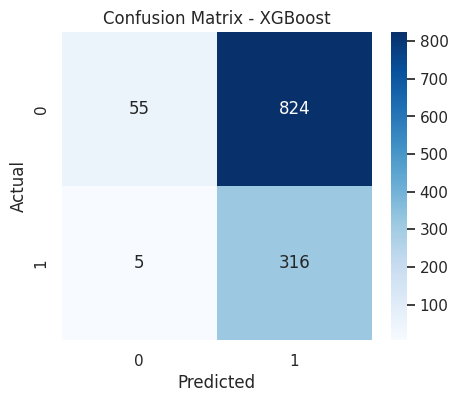

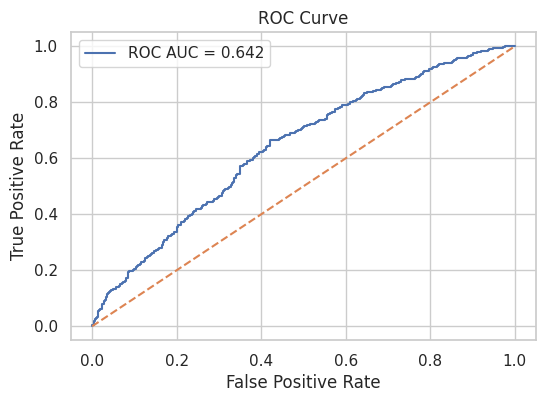

In [ ]:
# ============================================================
# 13. Threshold optimization & final evaluation
# ============================================================
def choose_threshold(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    df = pd.DataFrame({
        "threshold": np.r_[thresholds, 1.0],
        "precision": np.r_[precision[:-1], precision[-1]],
        "recall": np.r_[recall[:-1], recall[-1]]
    })
    df["f2"] = 5 * df["precision"] * df["recall"] / (4 * df["precision"] + df["recall"] + 1e-9)
    best = df.sort_values("f2", ascending=False).iloc[0]
    return float(best["threshold"]), df

recommended_threshold, threshold_table = choose_threshold(y_valid, valid_probs[best_model_name])
print("recommended_threshold:", round(recommended_threshold, 4))
display(threshold_table.sort_values("f2", ascending=False).head(10))

test_prob = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, "predict_proba") else best_model.predict(X_test)
test_pred = (test_prob >= recommended_threshold).astype(int)

final_metrics = pd.DataFrame([{
    "model": best_model_name,
    "threshold": recommended_threshold,
    "roc_auc": roc_auc_score(y_test, test_prob),
    "pr_auc": average_precision_score(y_test, test_prob),
    "precision": precision_score(y_test, test_pred, zero_division=0),
    "recall": recall_score(y_test, test_pred, zero_division=0),
    "f1": f1_score(y_test, test_pred, zero_division=0),
    "ks": ks_statistic(y_test, test_prob)
}])

display(final_metrics)
print(classification_report(y_test, test_pred, digits=4))

cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr, tpr, _ = roc_curve(y_test, test_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, test_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


,feature,importance
9,num__Previous_Defaults,0.013651
7,num__Debt_to_Income,0.013270
1,num__Credit_Score,0.008207
6006,cat__Registration_Date_2021-01-01 00:00:00,0.007663
6046,cat__Registration_Date_2024-05-01 00:00:00,0.007335
5761,cat__Gender_Male,0.007086
108,cat__Loan_Purpose_Travel Package,0.006855
6037,cat__Registration_Date_2023-08-01 00:00:00,0.006306
5770,cat__Country_Italy,0.006151
13,num__Annual_Income,0.006002


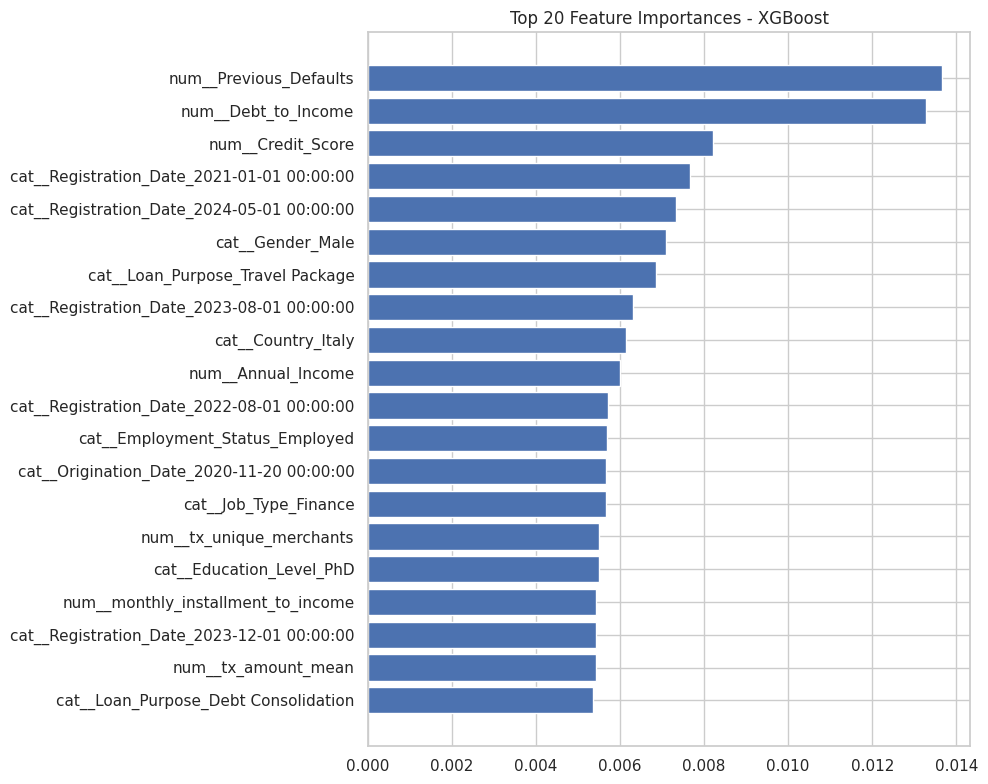

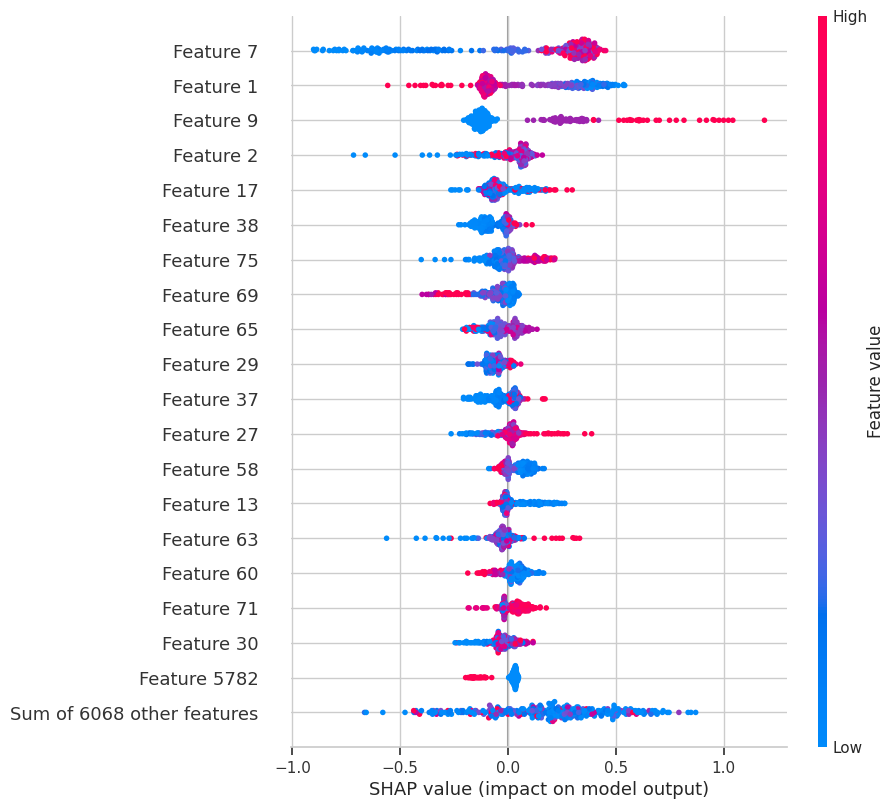

In [ ]:
# ============================================================
# 14. Feature importance & interpretability
# ============================================================
feature_names = preprocessor.get_feature_names_out()
importance_df = None

if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": best_model.feature_importances_
    }).sort_values("importance", ascending=False)
elif hasattr(best_model, "coef_"):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": np.abs(best_model.coef_[0])
    }).sort_values("importance", ascending=False)

if importance_df is not None:
    display(importance_df.head(25))
    plt.figure(figsize=(10, 8))
    plot_df = importance_df.head(20).sort_values("importance")
    plt.barh(plot_df["feature"], plot_df["importance"])
    plt.title(f"Top 20 Feature Importances - {best_model_name}")
    plt.tight_layout()
    plt.show()

if HAS_SHAP:
    try:
        explainer = shap.Explainer(best_model, X_train[:min(500, len(X_train))])
        shap_values = explainer(X_valid[:min(300, len(X_valid))])
        shap.plots.beeswarm(shap_values, max_display=20)
    except Exception as e:
        print("SHAP skipped:", e)


In [ ]:
# ============================================================
# 15. Final scoring function
# ============================================================
TRAINING_FEATURES = FEATURES.copy()

def predict_credit_risk(loan_id, threshold=None):
    """
    Predict default risk for a loan_id from analytic_df.
    Returns:
        {
            "loan_id": ...,
            "risk_score": ...,
            "probability_of_default": ...,
            "decision": "ACCEPT" / "REJECT"
        }
    """
    if threshold is None:
        threshold = recommended_threshold

    row = analytic_df[analytic_df["Loan_ID"] == loan_id].copy()
    if row.empty:
        raise ValueError(f"Loan_ID not found: {loan_id}")

    for c in TRAINING_FEATURES:
        if c not in row.columns:
            row[c] = np.nan

    X_new = preprocessor.transform(row[TRAINING_FEATURES])
    prob = float(best_model.predict_proba(X_new)[:, 1][0]) if hasattr(best_model, "predict_proba") else float(best_model.predict(X_new)[0])
    risk_score = int(round(prob * 1000))
    decision = "REJECT" if prob >= threshold else "ACCEPT"

    return {
        "loan_id": loan_id,
        "risk_score": risk_score,
        "probability_of_default": prob,
        "decision": decision
    }

sample_loan_id = analytic_df["Loan_ID"].iloc[0]
predict_credit_risk(sample_loan_id)


{'loan_id': 'LOAN_00001',
 'risk_score': 249,
 'probability_of_default': 0.24866345524787903,
 'decision': 'REJECT'}

## Conclusion

Ce notebook corrigé :
- garde une seule logique d’entraînement,
- évite les conflits entre plusieurs modèles finaux,
- garantit la cohérence entre les features d’entraînement et de prédiction,
- ajoute une vraie comparaison de modèles,
- fournit une fonction finale unique `predict_credit_risk(...)`.
